In [71]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler 
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

# 프로젝트1 [기술통계분석+그래프] 와인품질등급 예측하기

1. 데이터셋 출처
* 본 데이터셋은 UCI 머신러닝 저장소에서 제공하는 와인 품질 데이터로, 레드 와인과 화이트 와인의 두 가지 파일로 구성되어 있습니다. 목표는 물리화학적 테스트를 기반으로 와인 품질을 모델링하는 것입니다
* 출처: https://archive.ics.uci.edu/dataset/186/wine+quality
* 파일명: winequality-red.csv, winequality-white.csv

2. 데이터구성
와인의 화학적 성분 11개와 품질 등급(0~10점)으로 이루어져 있습니다.

* type 와인 종류레드(red) 또는 화이트(white)
* fixed_acidity 고정 산도와인의 산성도와 관련된 주요 산 성분
* volatile_acidity(볼러타일 어시디티) 휘발성 산도와인의 향에 영향을 주는 휘발성 산(식초향)
* citric_acid(시트릭 애시드) 구연산와인의 신선함을 주는 산 성분
* residual_sugar(레지듀얼 슈거) 잔류 당분발효 후 남은 설탕 양 (단맛 결정)
* chlorides(클로라이즈) 염화물와인의 짠맛을 결정하는 소금 함량
* free_sulfur_dioxide(프리 설퍼 다이옥사이) 유리 이산화황산화 방지 및 미생물 번식 억제 역할
* total_sulfur_dioxide 총 이산화황유리 이산화황에 결합된 이산화황을 합친 양
* density 밀도알코올과 당분 함량에 따라 달라지는 밀도pH산도(pH)와인의 산성 혹은 알칼리성 정도 (보통 3.0~4.0)
* sulphates 황산염와인 보존제 역할을 하는 첨가물
* alcohol 알코올 도수와인의 알코올 함량 정도
* quality 품질(Target)0~10 사이의 품질 등급 (종속변수)

## 필요 라이브러리 설치
uv add pandas numpy seaborn matplotlib scipy statsmodels

In [2]:
import os                      # 운영체제와 상호작용하여 파일 경로 생성 및 관리 담당
import pandas as pd            # 데이터프레임 생성, 병합, 전처리 등 데이터 분석의 핵심 도구
import numpy as np             # 수치 계산 및 다차원 배열 처리를 위한 기본 라이브러리
import seaborn as sns          # Matplotlib 기반의 고수준 데이터 시각화 도구 (통계 그래픽),빠르고 예쁘게
import matplotlib.pyplot as plt # 파이썬의 가장 기본적인 그래프 및 시각화 라이브러리,그래프의 제목(Title), 축 이름(Label), 그림 크기(figsize) 등을 세밀하게 다듬습니다.

# stats: t-검정, 상관분석 등 통계 검정용 함수
# ols: 일반 선형회귀 모델
# glm: 정규분포가 아닐 때 사용하는 확장된 회귀 모델
# 회귀분석을 통해 각 성분이 와인 품질에 유의미한 영향을 주는지 p-value로 판단
from scipy import stats         
from statsmodels.formula.api import ols, glm

# 데이터 분석·머신러닝용
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

# 시각화 기본 설정
sns.set_style('darkgrid')      # 차트 배경에 격자 무늬 설정
plt.rcParams['figure.figsize'] = [10, 6] # 그래프의 기본 크기(가로 10, 세로 6) 설정

print("와인 분석을 위한 라이브러리 로드 완료")

와인 분석을 위한 라이브러리 로드 완료


## 데이터 수집

In [14]:
#1. csv 파일 세미콜론(;) 구분자로 읽어오기 
red_df = pd.read_csv('../../data/winequality-red.csv', sep = ';', header = 0, engine = 'python')
white_df = pd.read_csv('../../data/winequality-white.csv', sep = ';', header = 0, engine= 'python')

In [15]:
red_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
white_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## 데이터 병합

In [17]:
red_df.insert(0, column='type', value='red')
red_df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
white_df.insert(0, column='type', value='white')
white_df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [22]:
print("red", red_df.shape)
print("white", white_df.shape)

red (1599, 13)
white (4898, 13)


In [ ]:
# 데이터 병합
wine = pd.concat([red_df, white_df])
wine.shape

(6497, 13)

In [ ]:
## csv 파일로 저장 (백업데이터)
wine.to_csv('../../data/wine.csv', index=False)

# 데이터 탐색

## 기술통계분석

In [26]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 710.6+ KB


In [27]:
# 항목명의 공백을 '_'로 대체
wine.columns = wine.columns.str.replace(' ', '_')
wine.head()

,type,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# 통계량 확인
wine.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
# tolist() 를 사용하여 일반 리스트로 표시, 없으면 좀더 자세하게 보임
sorted(wine.quality.unique().tolist())  

[3, 4, 5, 6, 7, 8, 9]

In [32]:
wine.quality.value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

In [ ]:
# 그룹별 품질 빅교하기
wine.groupby('type')['quality'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
red,1599.0,5.636023,0.807569,3.0,5.0,6.0,6.0,8.0
white,4898.0,5.877909,0.885639,3.0,5.0,6.0,6.0,9.0


In [35]:
wine.groupby('type')['quality'].mean()

type
red      5.636023
white    5.877909
Name: quality, dtype: float64

In [36]:
wine.groupby('type')['quality'].std()

type
red      0.807569
white    0.885639
Name: quality, dtype: float64

In [37]:
wine.groupby('type')['quality'].agg(['mean', 'std', 'count'])

,mean,std,count
type,,,
red,5.636023,0.807569,1599
white,5.877909,0.885639,4898


In [ ]:
red_wine_quality = wine.loc[wine['type'] == 'red', 'quality']
white_wine_quality = wine.loc[wine['type'] == 'white', 'quality']

In [41]:
print("red\n", red_wine_quality, sep='') 
print("white\n", white_wine_quality, sep='') 

red
0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64
white
0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64


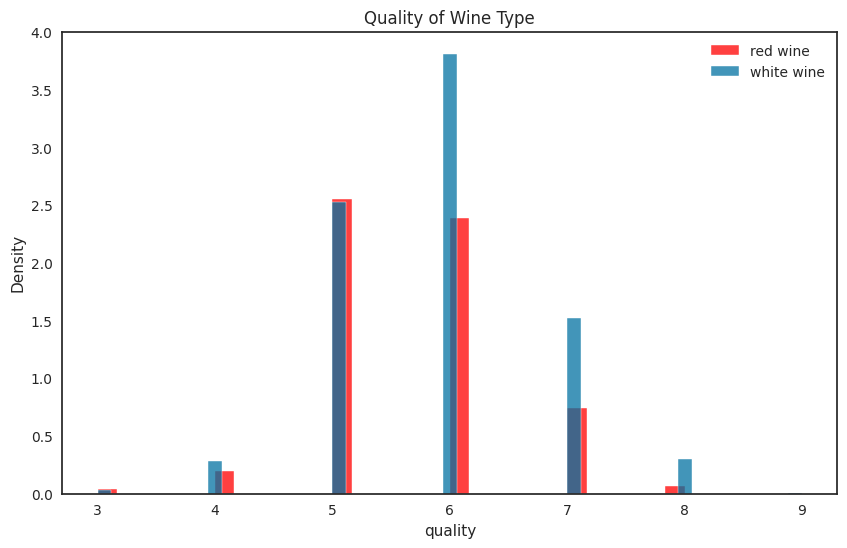

In [43]:
sns.set_style('white')
sns.histplot(red_wine_quality, stat='density', color = "red", label = 'red wine', multiple='dodge')
sns.histplot(white_wine_quality, stat='density', label = 'white wine', multiple='dodge')    
plt.title("Quality of Wine Type") # 그래프 제목
plt.legend()                      # 어떤 색이 어떤 와인인지 알려주는 범례 표시
plt.show()

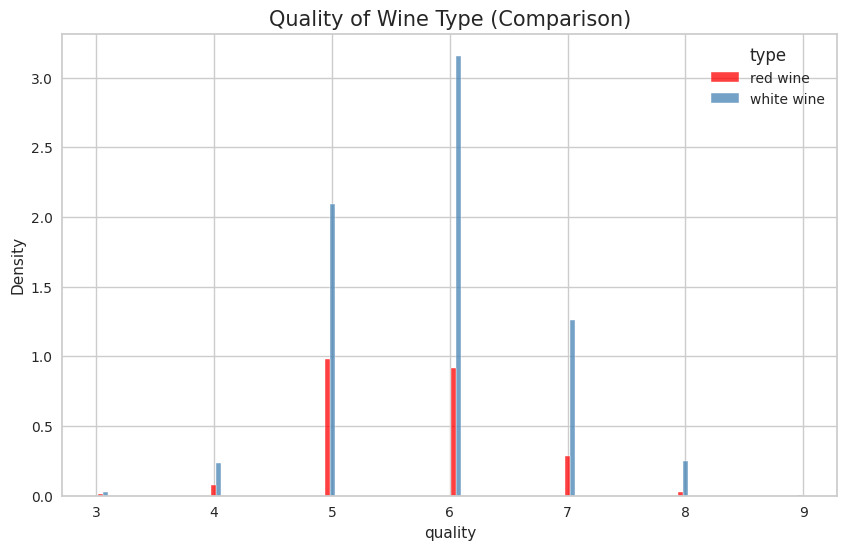

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시각화용 통합 데이터프레임 만들기 (이게 핵심입니다!)
red_df = pd.DataFrame({'quality': red_wine_quality, 'type': 'red wine'})
white_df = pd.DataFrame({'quality': white_wine_quality, 'type': 'white wine'})
combined_wine = pd.concat([red_df, white_df])

# 2. 배경 설정 및 그래프 그리기
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

# data=combined_wine 로 통합 데이터를 넣고, hue='type'으로 그룹을 지정합니다.
# shrink=0.8을 주면 막대 사이에 여백이 생겨서 절대 안 겹치고 깔끔해집니다.
sns.histplot(data=combined_wine, x='quality', hue='type', 
             stat='density', multiple='dodge', shrink=0.8,
             palette={'red wine': 'red', 'white wine': 'steelblue'})

plt.title("Quality of Wine Type (Comparison)", fontsize=15)
plt.show()

In [ ]:
# t-검정실행
stats.ttest_ind(red_wine_quality, white_wine_quality, equal_var=False) # pvalue < 0.05 이므로 품질에 차이가 있다

TtestResult(statistic=np.float64(-10.149363059143164), pvalue=np.float64(8.168348870049682e-24), df=np.float64(2950.750452166697))

In [49]:
# 11개의 성분이 품질에 얼마나 영향을 주는가? 
r = 'quality ~ fixed_acidity + volatile_acidity + citric_acid + residual_sugar + chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + sulphates + alcohol'
regression_result = ols(r, data = wine).fit()
regression_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     243.3
Date:                Mon, 19 Jan 2026   Prob (F-statistic):               0.00
Time:                        19:59:39   Log-Likelihood:                -7215.5
No. Observations:                6497   AIC:                         1.445e+04
Df Residuals:                    6485   BIC:                         1.454e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               55.7627     11.894      4.688      0.000      32.447      79.079
fixed_acidity            0.0677      0.016      4.346      0.000       0.037       0.098
volatile_acidity        -1.3279      0.077    -17.162      0.000      -1.480      -1.176
citric_acid             -0.1097      0.080     -1.377      0.168      -0.266       0.046
residual_sugar           0.0436      0.005      8.449      0.000       0.033       0.054
chlorides               -0.4837      0.333     -1.454      0.146      -1.136       0.168
free_sulfur_dioxide      0.0060      0.001      7.948      0.000       0.004       0.007
total_sulfur_dioxide    -0.0025      0.000     -8.969      0.000      -0.003      -0.002
density                -54.9669     12.137     -4.529      0.000     -78.760     -31.173
pH                       0.4393      0.090      4.861      0.000       0.262       0.616
sulphates                0.7683      0.076     10.092      0.000       0.619       0.917
alcohol                  0.2670      0.017     15.963      0.000       0.234       0.300
==============================================================================
Omnibus:                      144.075   Durbin-Watson:                   1.646
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              324.712
Skew:                          -0.006   Prob(JB):                     3.09e-71
Kurtosis:                       4.095   Cond. No.                     2.49e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.49e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# 데이터 예측 및 시각화

In [51]:
sample1 = wine[wine.columns.difference(['quality', 'type'])] # 품질(quality)과 와인 종류(type)를 제외한 성분 데이터만 선택
sample1 = sample1[0:20]  # 앞의 20개 와인 샘플만 추출
sample1_predict = regression_result.predict(sample1) # 회귀모델을 이용해 와인 품질 점수 예측
sample1_predict

0     4.997607
1     4.924993
2     5.034663
3     5.680333
4     4.997607
5     5.043903
6     5.017701
7     5.302454
8     5.238861
9     5.690760
10    4.967877
11    5.690760
12    5.263028
13    5.681714
14    5.184065
15    5.219619
16    5.925258
17    5.431179
18    5.033491
19    5.517900
dtype: float64

In [52]:
compare_result = pd.DataFrame({
    '예측 점수': sample1_predict,
    '실제 점수': wine.iloc[0:20]['quality']
})

print(compare_result)

       예측 점수  실제 점수
0   4.997607      5
1   4.924993      5
2   5.034663      5
3   5.680333      6
4   4.997607      5
5   5.043903      5
6   5.017701      5
7   5.302454      7
8   5.238861      7
9   5.690760      5
10  4.967877      5
11  5.690760      5
12  5.263028      5
13  5.681714      5
14  5.184065      5
15  5.219619      5
16  5.925258      7
17  5.431179      5
18  5.033491      4
19  5.517900      6


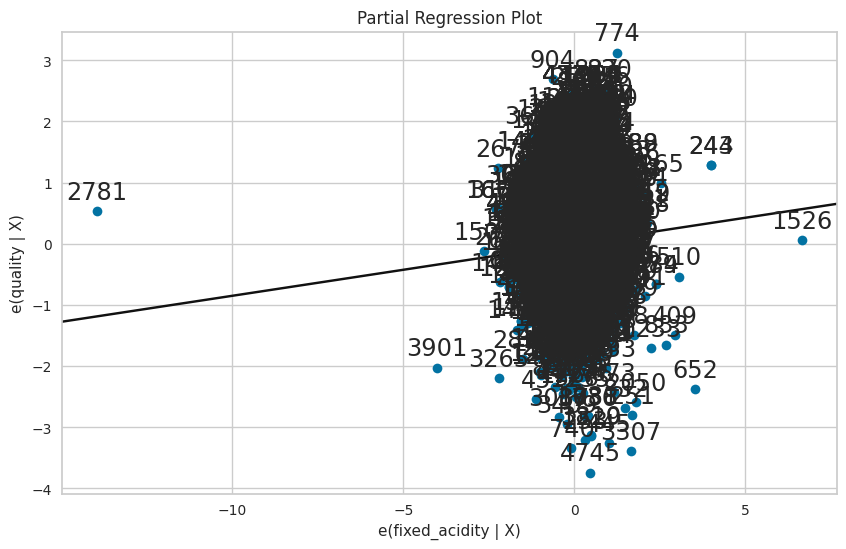

In [54]:
import statsmodels.api as sm

others = list(set(wine.columns).difference(set(["quality", "fixed_acidity"])))
p, resids = sm.graphics.plot_partregress(
    "quality",       # 결과(종속변수)
    "fixed_acidity", # 영향을 보고 싶은 성분(고정산)
    others,          # 나머지 성분들의 영향 제거
    data = wine,
    ret_coords = True
)
plt.show()

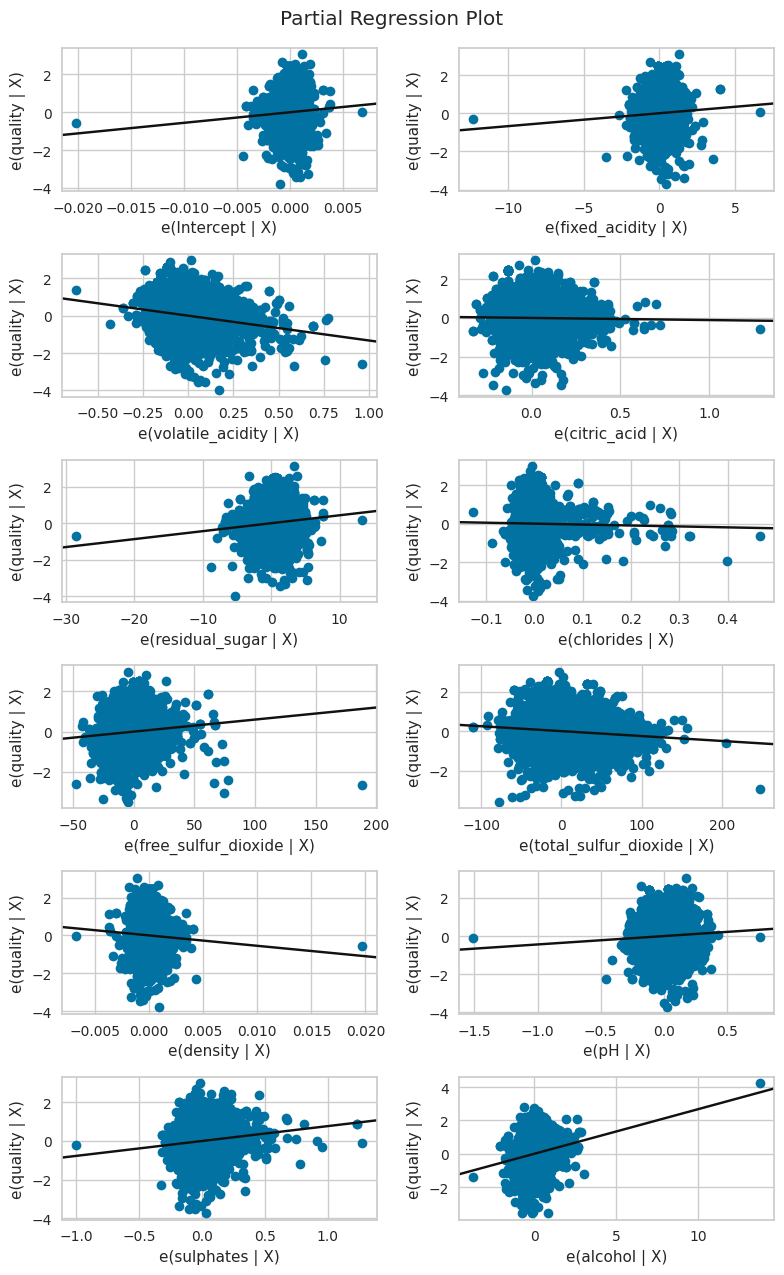

In [55]:
fig = plt.figure(figsize = (8, 13)) # 가로 8, 세로 13인치 크기
sm.graphics.plot_partregress_grid(regression_result, fig = fig)
plt.show()

# 주성분 분석

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [57]:
# 1. 특성과 타겟 분리
x = wine.drop(['quality', 'type'], axis=1)
y = wine['quality']

In [58]:
# 2. 데이터 표준화 (각 특성을 평균 0, 표준편차 1로 변환)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [59]:
# 3. PCA 적용
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(x_scaled)
print(f"선택된 주성분 개수: {pca.n_components_}")
print(f"주성분 분산 비율: {pca.explained_variance_ratio_}")

선택된 주성분 개수: 9
주성분 분산 비율: [0.2754426  0.22671146 0.14148609 0.08823201 0.06544317 0.05521016
 0.04755989 0.04559184 0.03063855]


In [60]:
feature_names = x.columns
components = pca.components_

In [65]:
# 4. 각 주성분의 분산 설명 비율 출력 각 주성분이 원 데이터 전체 분산에서 차지하는 비율 출력
# 첫 번째 주성분이 가장 많은 분산을 설명하고, 뒤로 갈수록 영향 적음
explained_variance_ratio = pca.explained_variance_ratio_
for i, ratio in enumerate(explained_variance_ratio):
    print(f"주성분 {i+1}의 분산 설명 비율: {ratio:.4f}")

주성분 1의 분산 설명 비율: 0.2754
주성분 2의 분산 설명 비율: 0.2267
주성분 3의 분산 설명 비율: 0.1415
주성분 4의 분산 설명 비율: 0.0882
주성분 5의 분산 설명 비율: 0.0654
주성분 6의 분산 설명 비율: 0.0552
주성분 7의 분산 설명 비율: 0.0476
주성분 8의 분산 설명 비율: 0.0456
주성분 9의 분산 설명 비율: 0.0306


In [66]:
# 5. 누적 분산 비율 출력
cumulative_variance = explained_variance_ratio.cumsum()
print("\n누적 분산 비율:")
for i, cum_ratio in enumerate(cumulative_variance):
    print(f"주성분 1~{i+1}까지의 누적 분산 비율: {cum_ratio:.4f}")


누적 분산 비율:
주성분 1~1까지의 누적 분산 비율: 0.2754
주성분 1~2까지의 누적 분산 비율: 0.5022
주성분 1~3까지의 누적 분산 비율: 0.6436
주성분 1~4까지의 누적 분산 비율: 0.7319
주성분 1~5까지의 누적 분산 비율: 0.7973
주성분 1~6까지의 누적 분산 비율: 0.8525
주성분 1~7까지의 누적 분산 비율: 0.9001
주성분 1~8까지의 누적 분산 비율: 0.9457
주성분 1~9까지의 누적 분산 비율: 0.9763


In [67]:
# PCA 차원축소 결과로 선형 회귀 모델을 학습
model = LinearRegression()
model.fit(x_pca, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
# R-squared 확인
y_pred = model.predict(x_pca)
print(f"PCA 회귀 R-squared: {r2_score(y, y_pred):.4f}")

PCA 회귀 R-squared: 0.2911


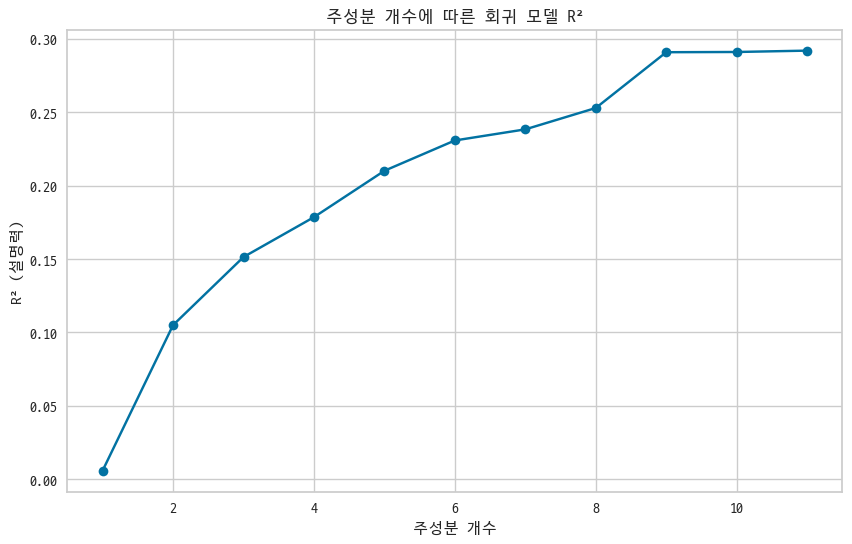

In [72]:
import matplotlib.pyplot as plt
import numpy as np

r2_list = []
n_components_list = list(range(1, x.shape[1]+1))

for n in n_components_list:
    pca_tmp = PCA(n_components=n)
    x_pca_tmp = pca_tmp.fit_transform(x_scaled)
    
    model_tmp = LinearRegression()
    model_tmp.fit(x_pca_tmp, y)
    y_pred_tmp = model_tmp.predict(x_pca_tmp)
    
    r2_tmp = r2_score(y, y_pred_tmp)
    r2_list.append(r2_tmp)

plt.figure(figsize=(10,6))
plt.plot(n_components_list, r2_list, marker='o')
plt.xlabel('주성분 개수')
plt.ylabel('R² (설명력)')
plt.title('주성분 개수에 따른 회귀 모델 R²')
plt.grid(True)
plt.show()

# 랜덤포레스트

In [73]:
# 1. 랜덤포레스트 회귀 모델 생성 (재션성을 위해 random_state 고정)
rf_model = RandomForestRegressor(random_state=42)

In [74]:
# 2. 모델 학습
rf_model.fit(x_scaled, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
# 3. 예측값 생성
y_pred_rf = rf_model.predict(x_scaled)

# 4. R-squared 점수 출력, 여러 개의 의사결정나무를 만들어 각 나무의 예측을 평균 내서 결과를 만드는 모델
r2_rf = r2_score(y, y_pred_rf)
print(f"랜덤포레스트 회귀 R²: {r2_rf:.4f}")

랜덤포레스트 회귀 R²: 0.9370


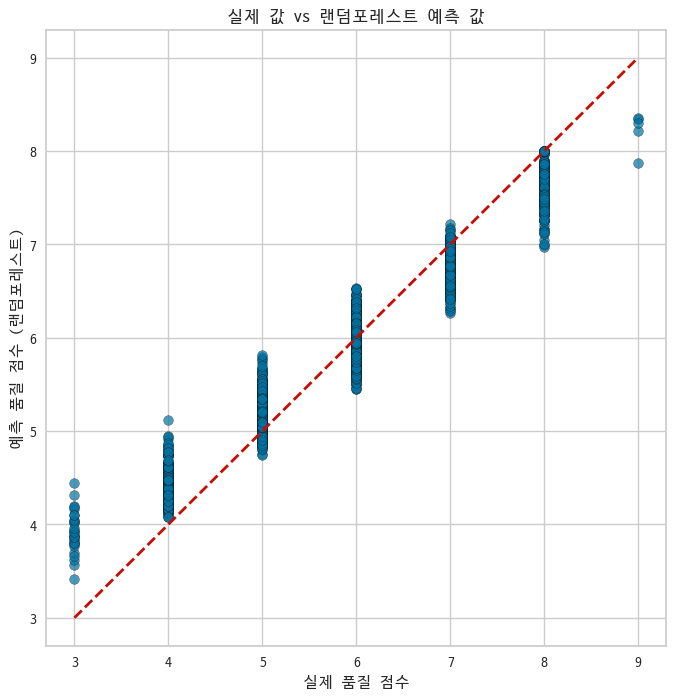

In [76]:
plt.figure(figsize=(8, 8))
plt.scatter(y, y_pred_rf, alpha=0.7, edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)  # 완벽 예측선 (y=x)
plt.xlabel('실제 품질 점수')
plt.ylabel('예측 품질 점수 (랜덤포레스트)')
plt.title('실제 값 vs 랜덤포레스트 예측 값')
plt.grid(True)
plt.show()

In [77]:
# 새 와인 데이터, 숫자와 칼럼명을 주어야 경고가 안남
x_new = pd.DataFrame(
    [[7.4, 0.70, 0.00, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]],
    columns=x.columns
)

# 2 표준화 
x_new_scaled = scaler.transform(x_new)

# 3. 예측
predicted_quality = rf_model.predict(x_new_scaled)
print(f"예측된 품질 점수: {predicted_quality[0]:.2f}")

예측된 품질 점수: 5.00
